In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from icecream import ic



In [3]:
C_e = 1.6e-19 # electron charge
e0 = 20.25 # background
omega_ex = 2 * C_e # exciton frequency Joules
f_0 = 0.2 # oscillator Hz
gamma_ex = 50e6 * C_e # not sure, 50MeV

def Re_dielectric(omega):
    numerator = (f_0 * (omega_ex**2) * ((omega_ex**2)-(omega**2)) )
    denominator = ( ((omega_ex**2) - (omega**2))**2 + (gamma_ex**2)*(omega**2) )
    return e0 + ( numerator / denominator )

def Im_dielectric(omega):
    numerator = (f_0 * (omega_ex**2) * gamma_ex * omega )
    denominator = ( ((omega_ex**2) - (omega**2))**2 + (gamma_ex**2)*(omega**2) )
    return ( numerator / denominator )

ic(Re_dielectric(C_e))
ic(Im_dielectric(C_e))

ic| Re_dielectric(C_e): 20.25
ic| Im_dielectric(C_e): 1.5999999999999948e-08


1.5999999999999948e-08

In [44]:
A = f_0 * (omega_ex**2)

def B(omega):
    numerator = (omega_ex**2) - (omega**2)
    denominator = ((omega_ex**2 - omega**2)**2 + (gamma_ex**2) * (omega**2))
    return numerator / denominator

def C(omega):
    numerator = (0.5 * gamma_ex * omega)
    denominator = ((omega_ex**2 - omega**2)**2 + (gamma_ex**2) * (omega**2))
    return numerator / denominator


def n(omega):
    f1 = A * C(omega) / 2
    f2 = (A * C(omega) / 2)**2
    f3 = ((e0 + A * B(omega)) / 3)**3
    sqrt_term = np.sqrt(f2 + f3)
    print(f1, sqrt_term)
    g1 = np.cbrt(f1 + sqrt_term)
    g2 = np.cbrt(f1 - sqrt_term)

    return g1 + g2
    

# Define omega values as a NumPy array
omega_values = np.logspace(-35, 35, 100000, base=10.)

# Compute n(omega) for all omega values
n_values = n(omega_values)

[3.90625000e-011 3.91255127e-011 3.91886271e-011 ... 4.13580439e-155
 4.11585408e-155 4.09600000e-155] [17.7974625  17.7974625  17.7974625  ... 17.53701443 17.53701443
 17.53701443]


[3.90625000e-011 3.91255127e-011 3.91886271e-011 ... 4.13580439e-155
 4.11585408e-155 4.09600000e-155] [17.7974625  17.7974625  17.7974625  ... 17.53701443 17.53701443
 17.53701443]


Text(0.5, 1.0, 'n')

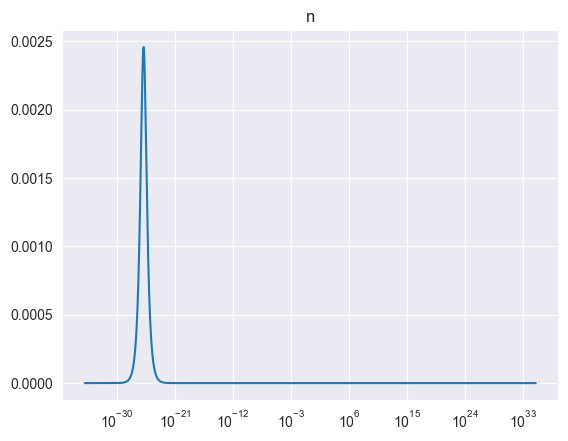

In [45]:
import matplotlib.pyplot as plt

plt.semilogx(omega_values, n(omega_values))
# plt.xlim([1e-30,1e-20])
plt.title('n')

In [37]:
print(Im_dielectric(np.array([1,])))


[1.6384e-49]


In [38]:
kappa = []
for i in omega_values:
    i_np = np.array([i,])
    
    if n(i)**2 < Re_dielectric(i):
        k = None
    else:    
        try:
            # k_np = Im_dielectric(i_np) / (2*n(i_np))
            
            k_np = np.sqrt( n(i)**2 - Re_dielectric(i) )
            k=k_np
        except:
            print(f"{i:.3f} has no value")
            k = None
    kappa.append(k)
    


3.906250000000001e-11 17.79746249599353
3.909489385108163e-11 17.79746249599353
3.9127314565819894e-11 17.79746249599353
3.9159762166492376e-11 17.79746249599353
3.919223667539511e-11 17.79746249599353
3.922473811484262e-11 17.79746249599353
3.925726650716794e-11 17.79746249599353
3.928982187472261e-11 17.79746249599353
3.9322404239876734e-11 17.79746249599353
3.935501362501831e-11 17.79746249599353
3.938765005255582e-11 17.79746249599353
3.9420313544914416e-11 17.79746249599353
3.9453004124538464e-11 17.79746249599353
3.948572181389098e-11 17.79746249599353
3.951846663545359e-11 17.79746249599353
3.955123861172656e-11 17.79746249599353
3.9584037765228815e-11 17.79746249599353
3.961686411849796e-11 17.79746249599353
3.964971769409029e-11 17.79746249599353
3.96825985145808e-11 17.79746249599353
3.971550660256321e-11 17.79746249599353
3.974844198064999e-11 17.79746249599353
3.9781404671472315e-11 17.79746249599353
3.9814394697680194e-11 17.79746249599353
3.9847412081942375e-11 17.7974624

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [48]:

kappa = np.sqrt(np.maximum(n(omega_values)**2 - Re_dielectric(omega_values), 0))

kappa = Im_dielectric(omega_values) / (2*n(omega_values)+1e-30)

[3.90625000e-011 3.91255127e-011 3.91886271e-011 ... 4.13580439e-155
 4.11585408e-155 4.09600000e-155] [17.7974625  17.7974625  17.7974625  ... 17.53701443 17.53701443
 17.53701443]
[3.90625000e-011 3.91255127e-011 3.91886271e-011 ... 4.13580439e-155
 4.11585408e-155 4.09600000e-155] [17.7974625  17.7974625  17.7974625  ... 17.53701443 17.53701443
 17.53701443]


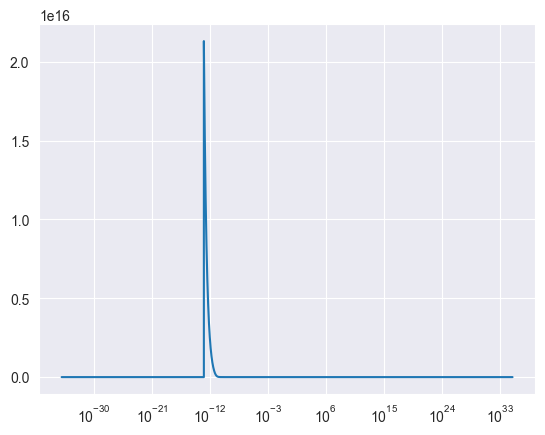

In [49]:
plt.semilogx(omega_values, kappa)
#plt.xlim([None,1e-15])

In [61]:
print()